In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_PATH = "../data/processed/no2_ground_station/ground_no2_2018_2019.csv"

In [3]:
ground_no2 = pd.read_csv(DATA_PATH)

In [4]:
stations = ground_no2["station"].unique().tolist()

## Basic Info

In [11]:
ground_no2.info()

<class 'pandas.DataFrame'>
RangeIndex: 2013837 entries, 0 to 2013836
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   From Date  str    
 1   To Date    str    
 2   NO2        float64
 3   lat        float64
 4   lon        float64
 5   station    str    
dtypes: float64(3), str(3)
memory usage: 92.2 MB


In [15]:
ground_no2.describe()

,NO2,lat,lon
count,2.013837e+06,2.013837e+06,2.013837e+06
mean,3.415705e+01,2.468485e+01,7.790610e+01
std,3.360638e+01,5.582401e+00,3.629011e+00
min,1.000000e-02,8.530240e+00,7.257140e+01
25%,1.295000e+01,2.182850e+01,7.621700e+01
50%,2.382000e+01,2.717670e+01,7.715194e+01
75%,4.385000e+01,2.865224e+01,7.773150e+01
max,4.998000e+02,3.163400e+01,9.189330e+01


## NO2 distribution per station

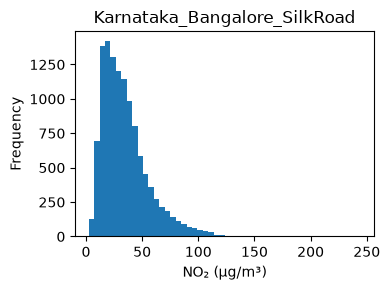

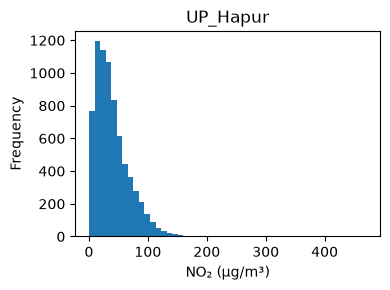

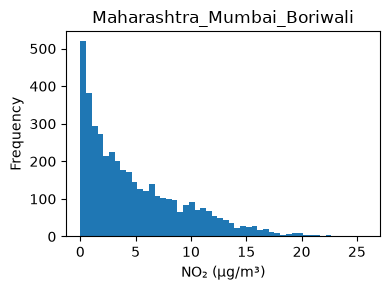

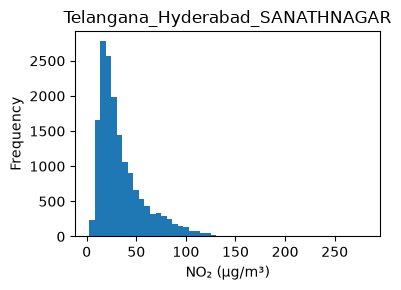

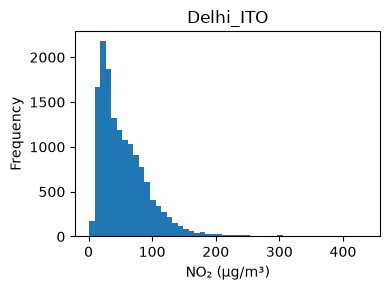

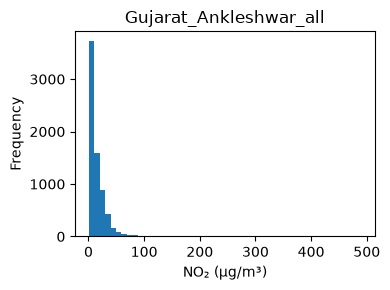

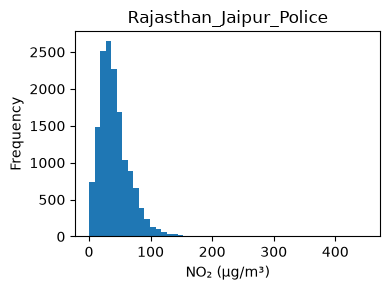

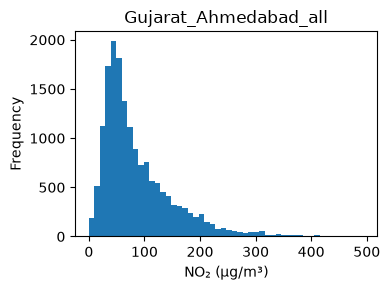

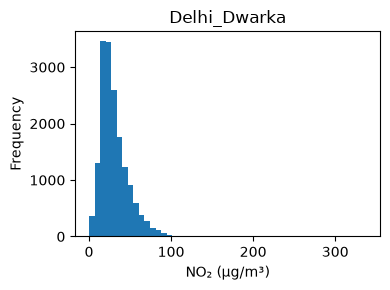

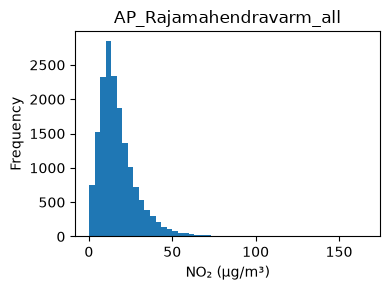

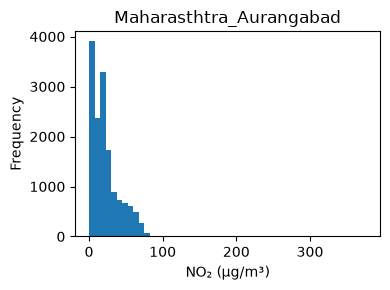

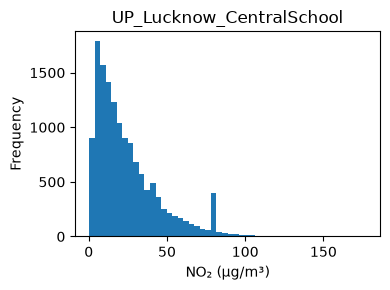

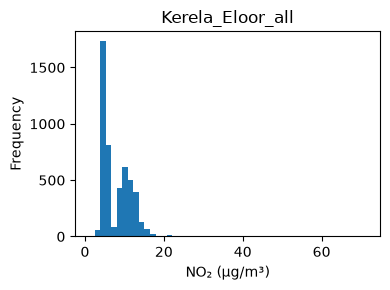

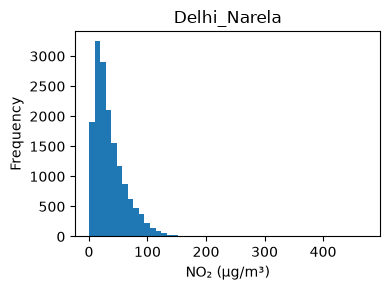

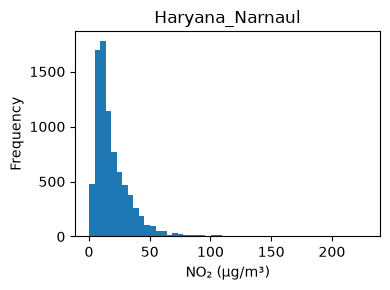

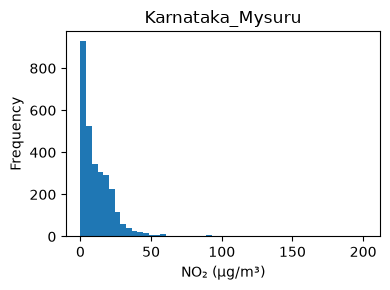

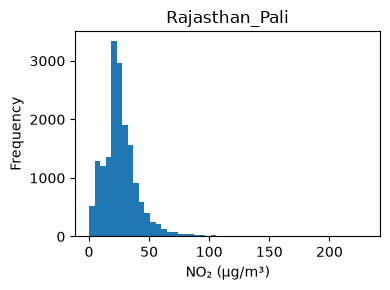

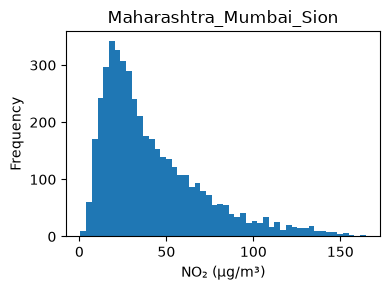

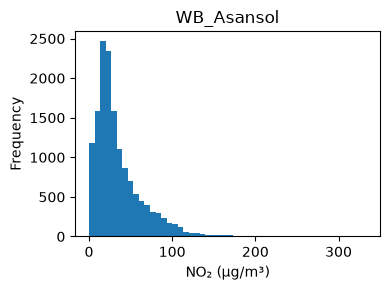

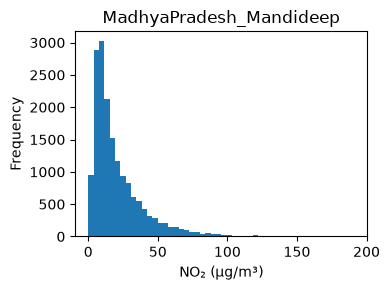

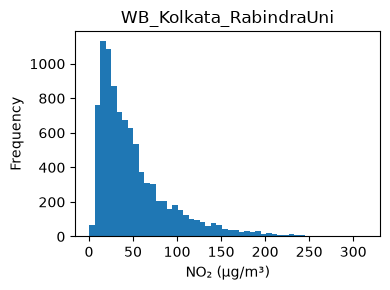

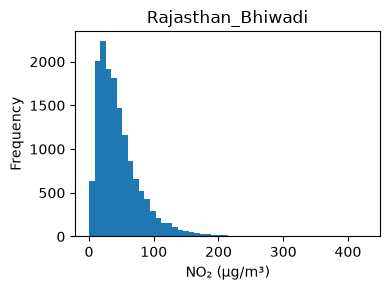

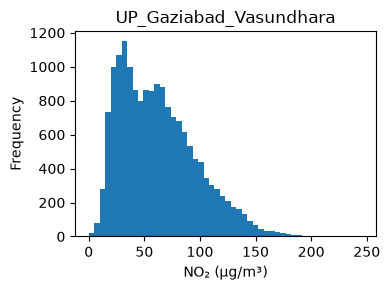

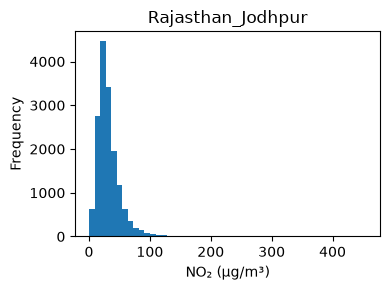

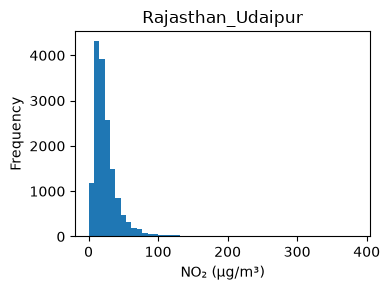

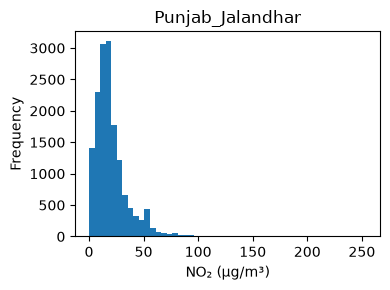

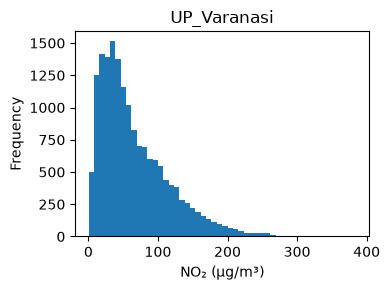

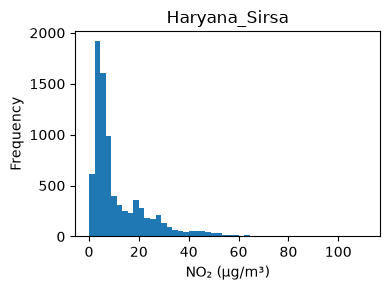

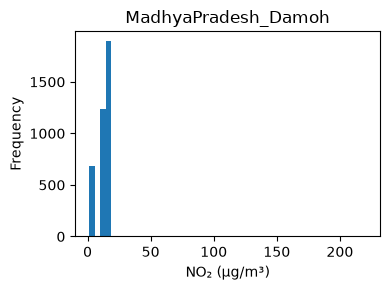

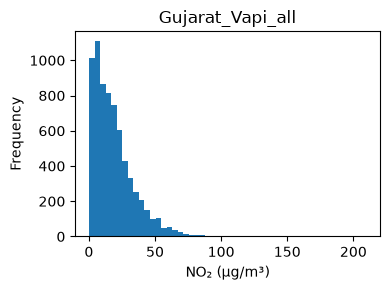

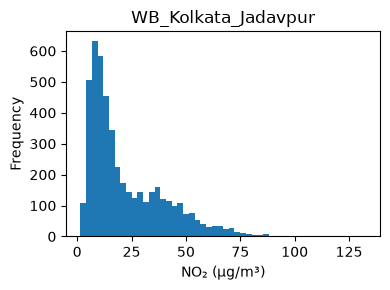

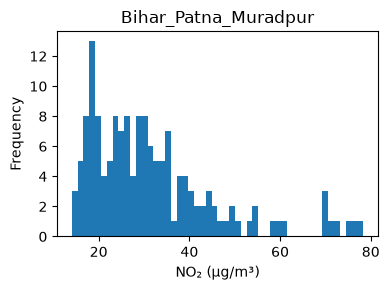

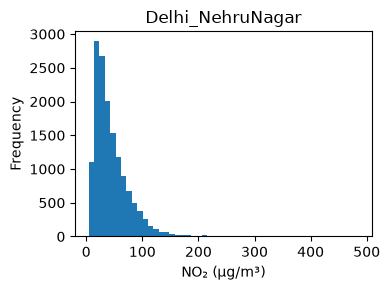

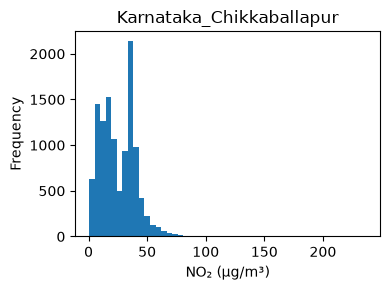

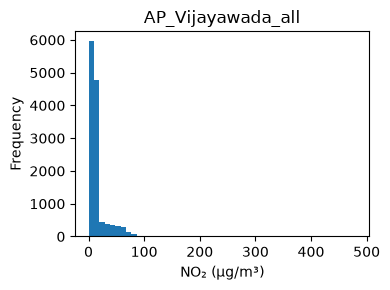

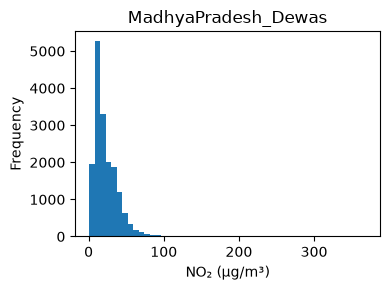

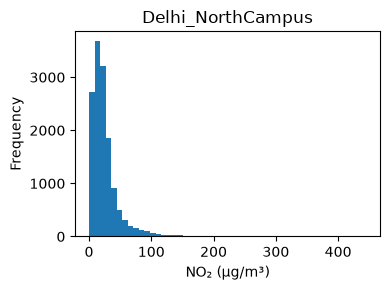

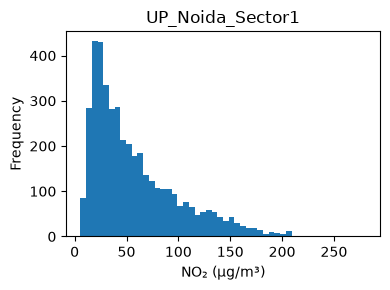

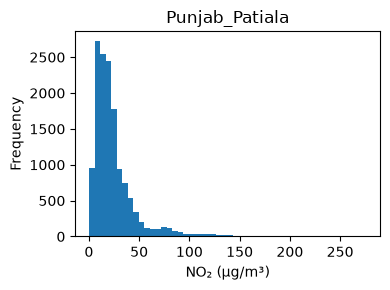

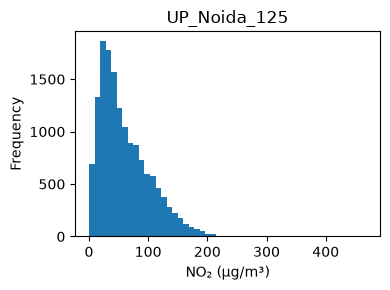

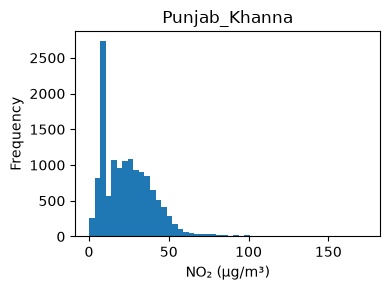

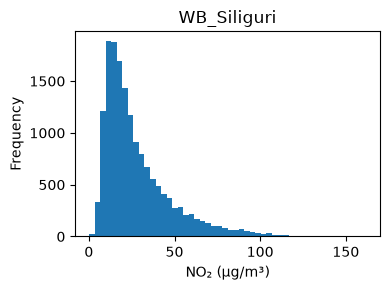

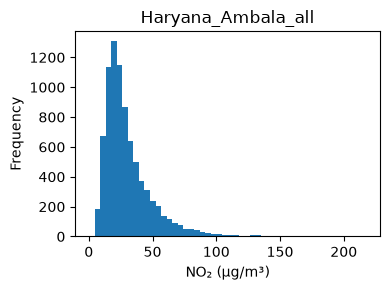

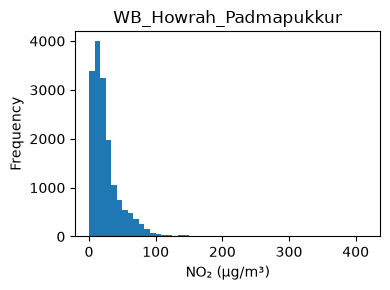

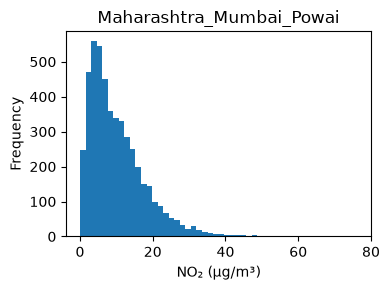

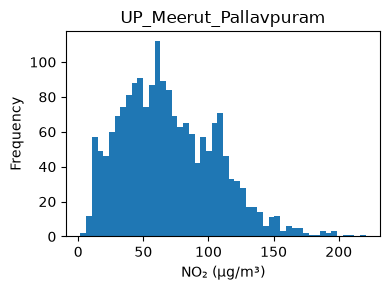

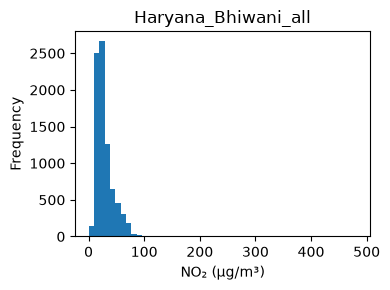

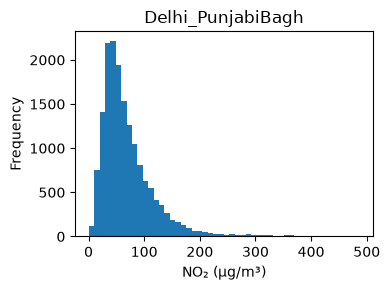

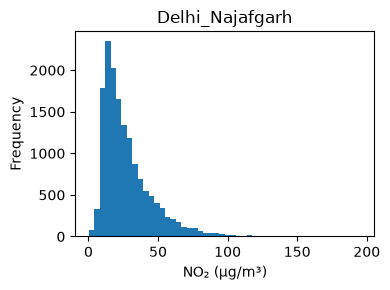

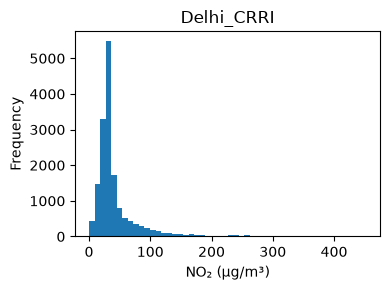

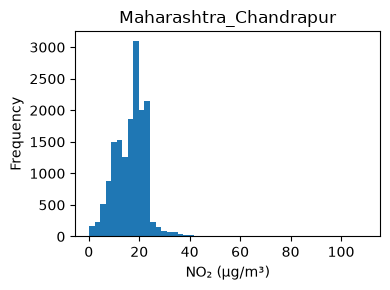

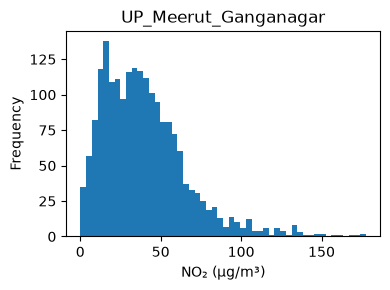

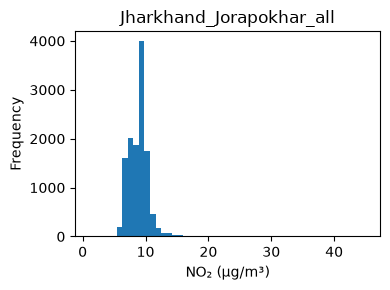

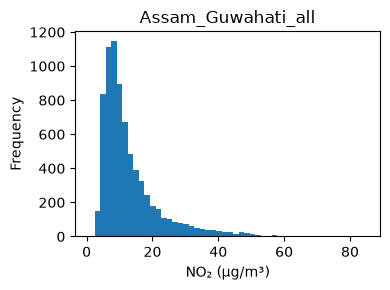

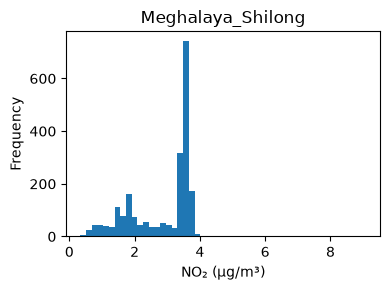

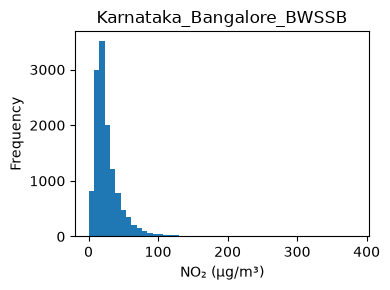

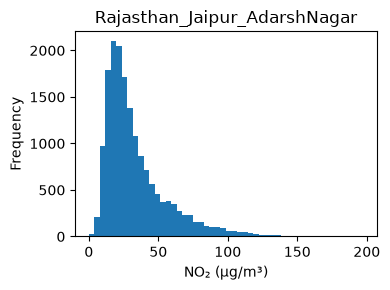

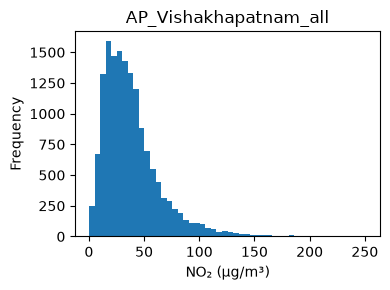

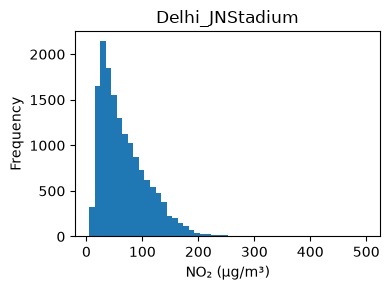

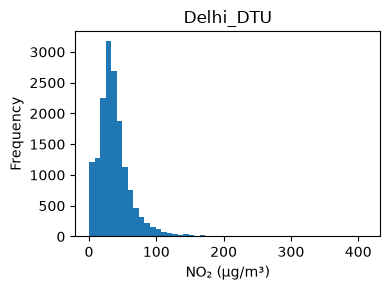

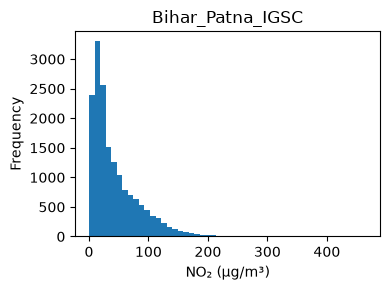

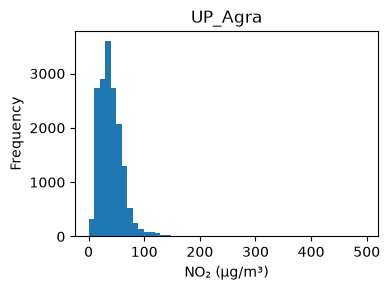

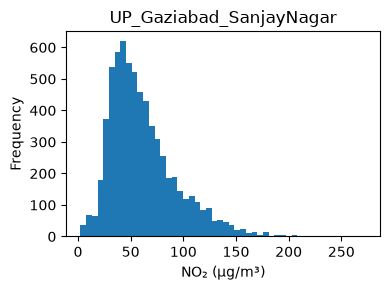

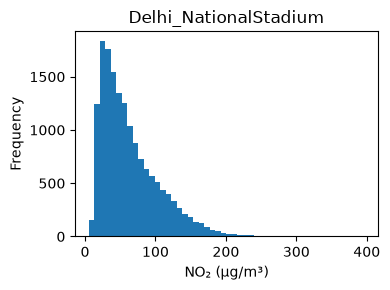

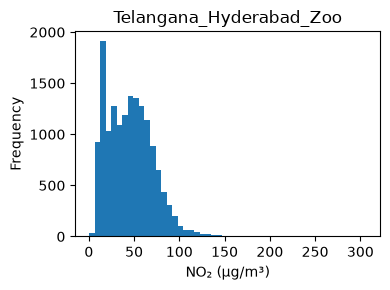

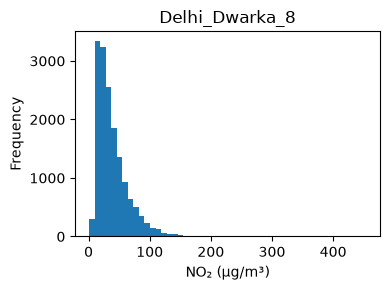

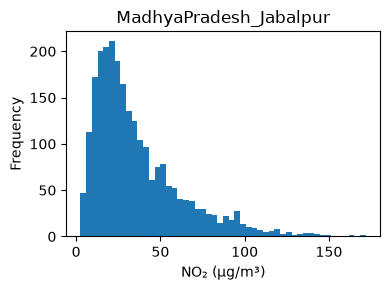

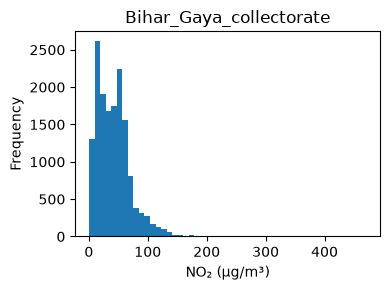

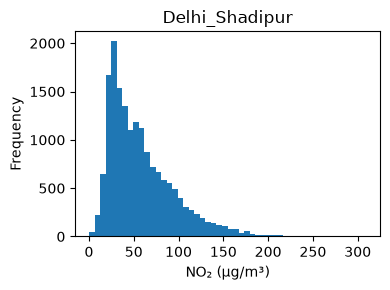

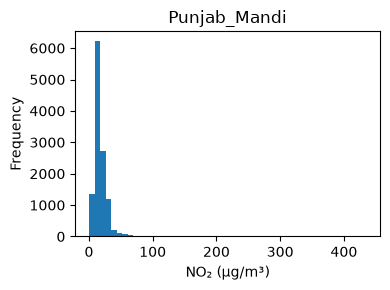

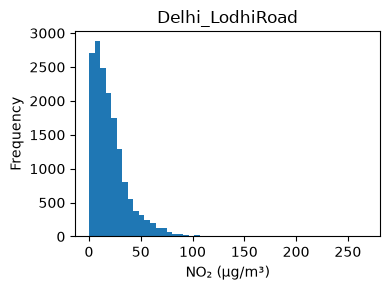

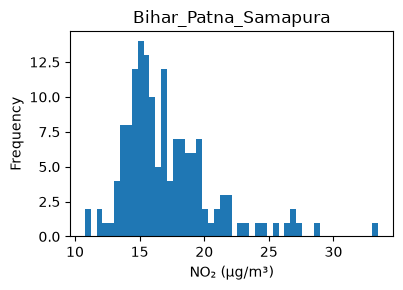

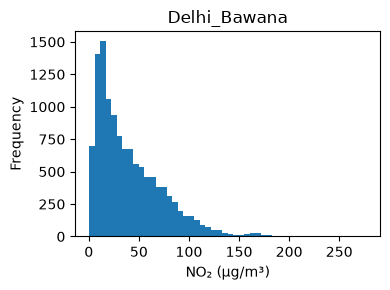

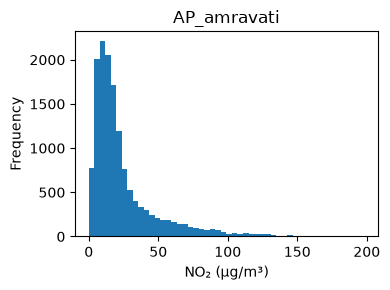

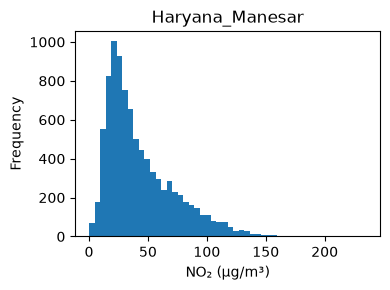

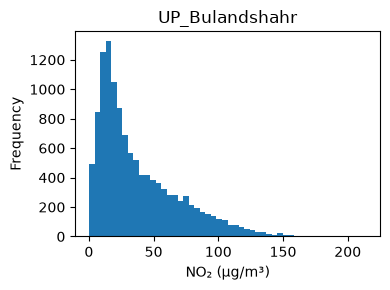

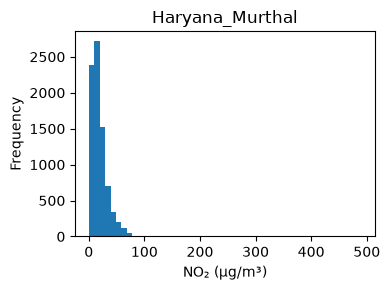

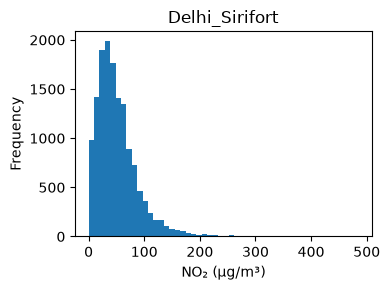

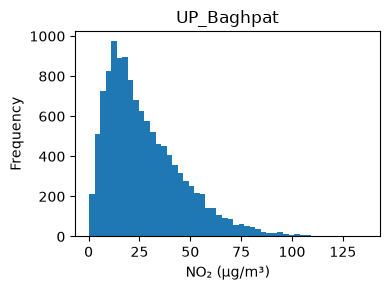

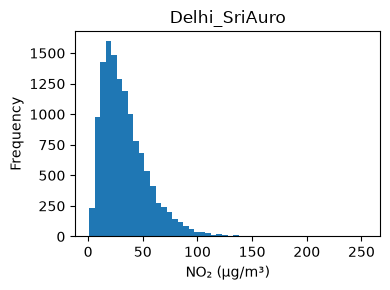

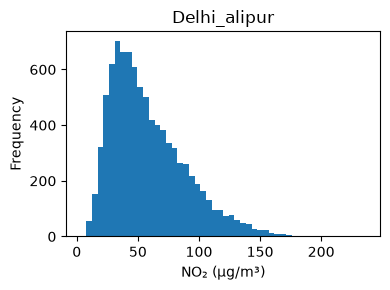

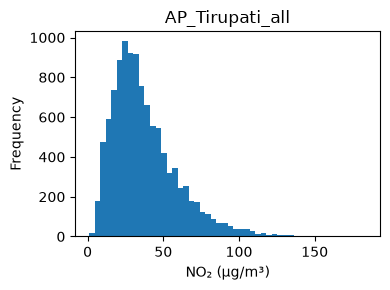

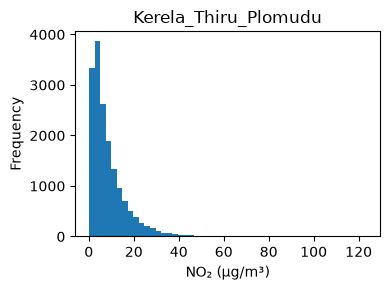

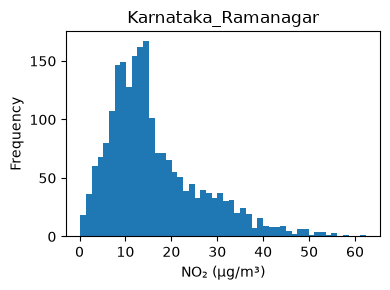

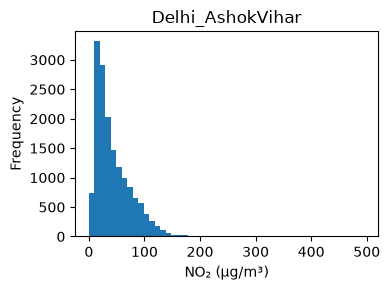

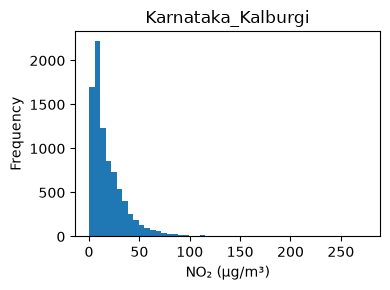

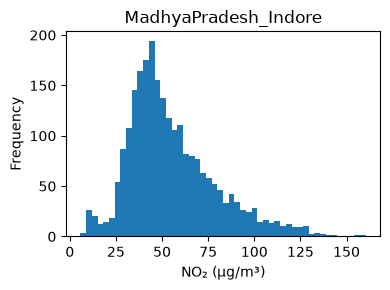

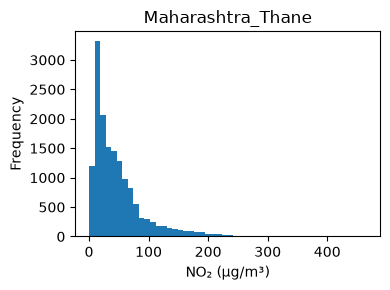

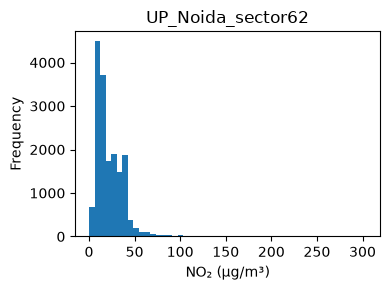

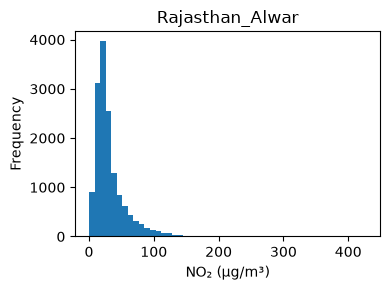

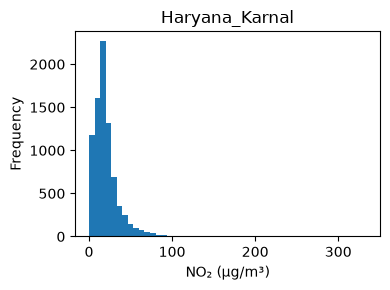

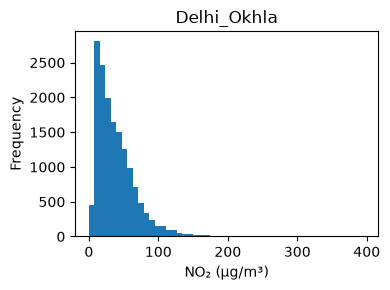

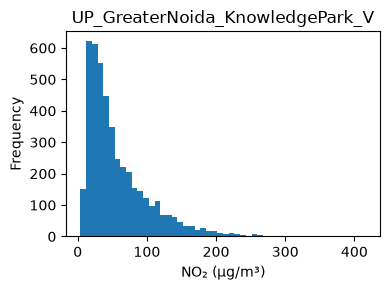

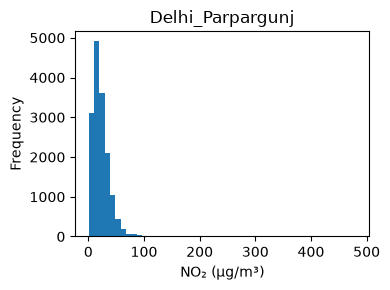

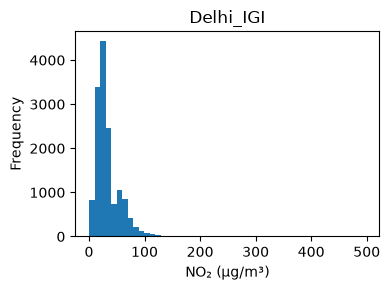

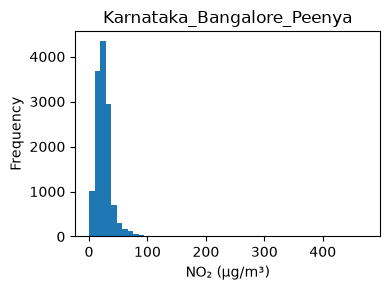

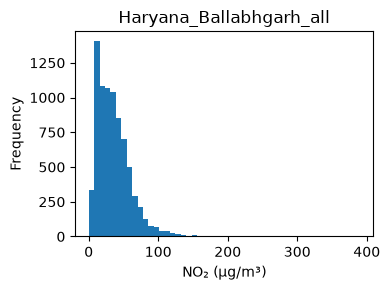

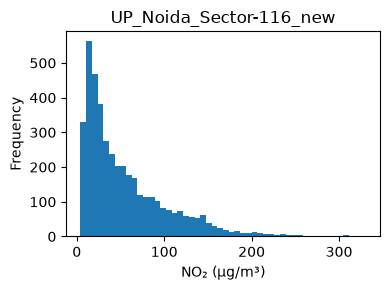

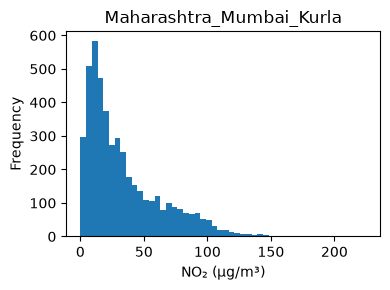

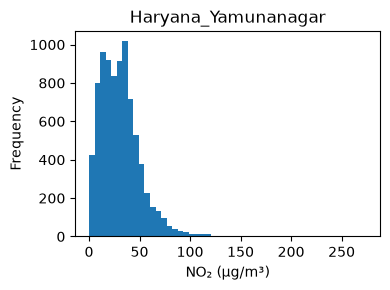

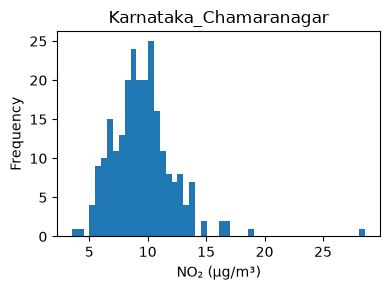

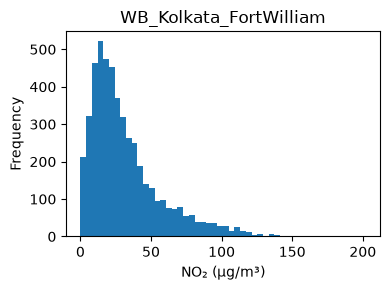

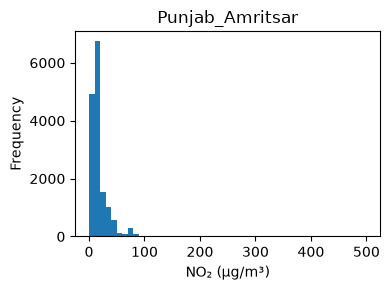

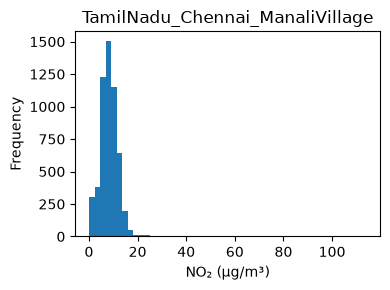

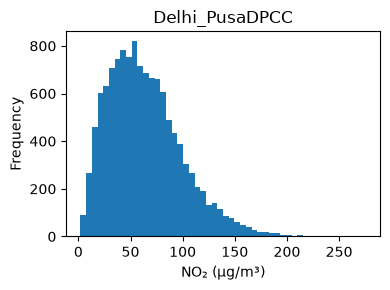

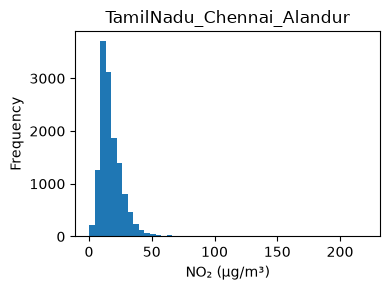

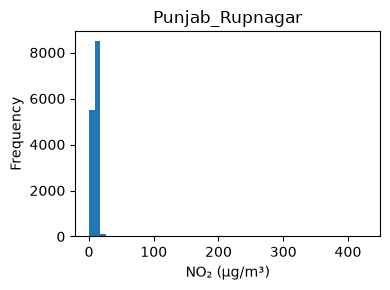

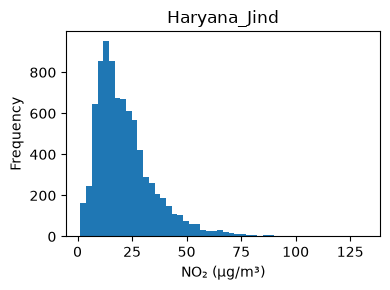

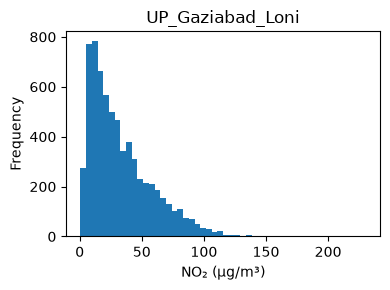

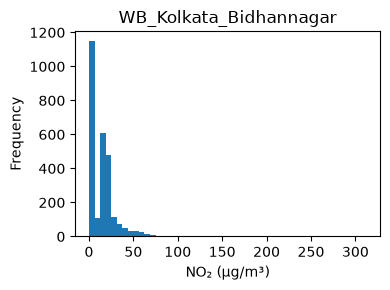

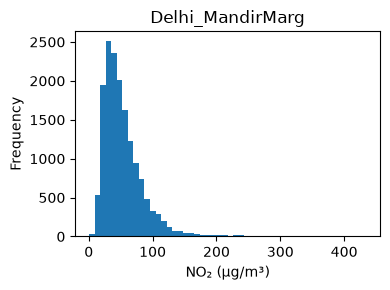

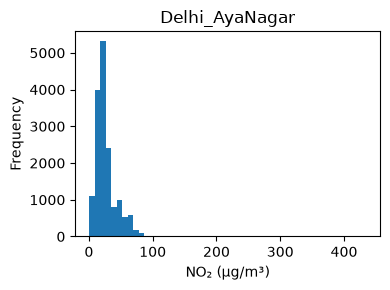

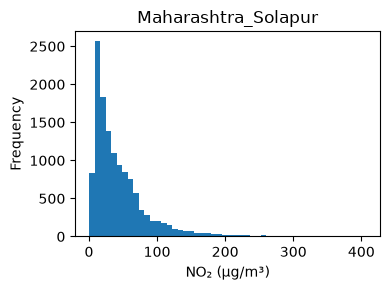

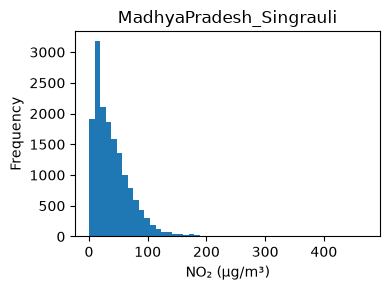

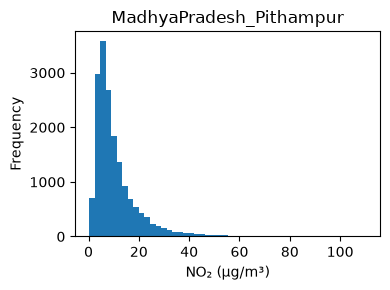

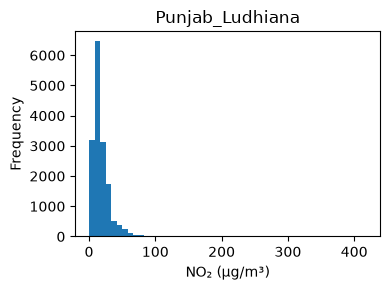

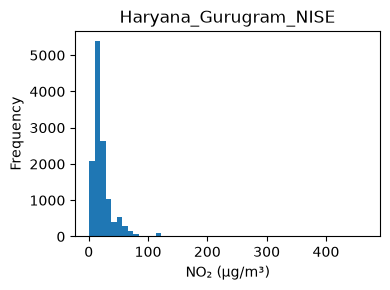

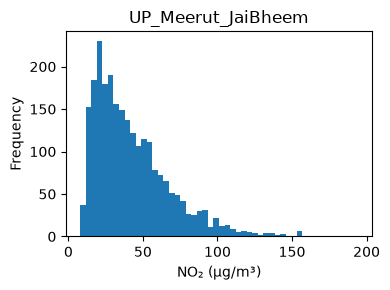

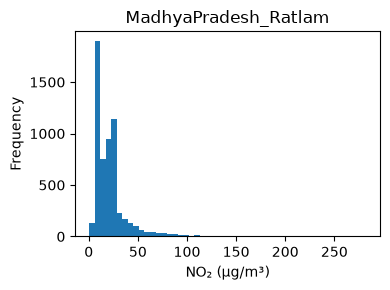

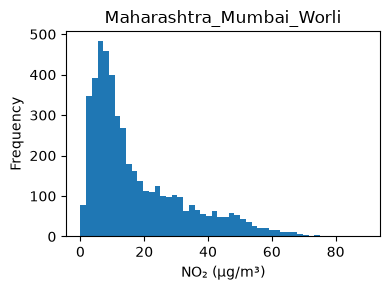

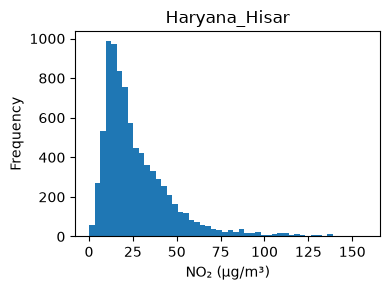

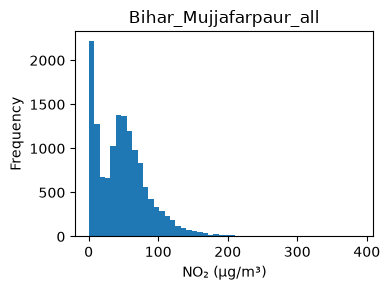

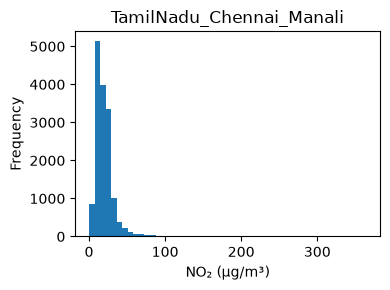

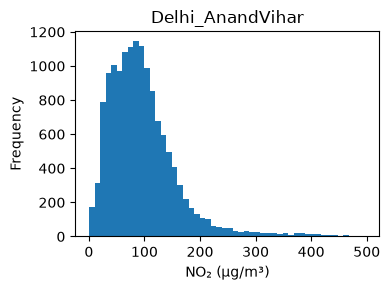

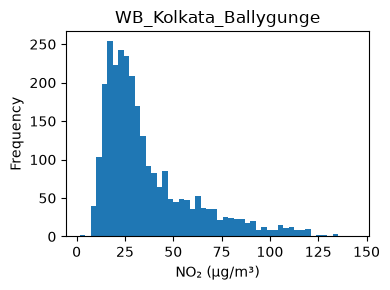

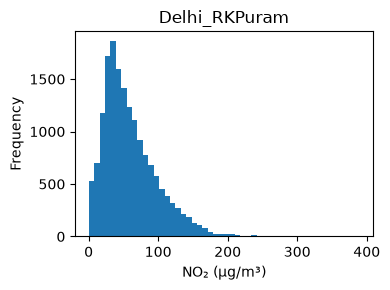

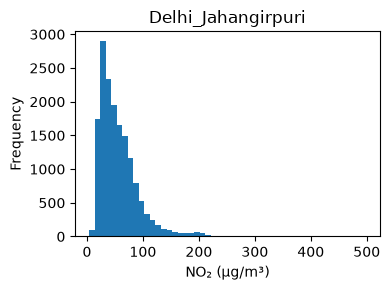

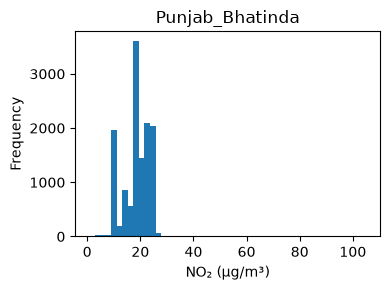

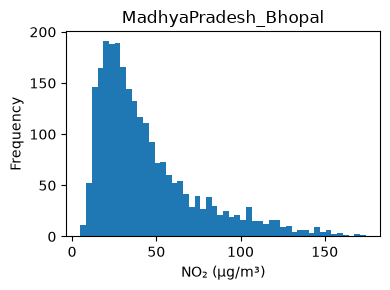

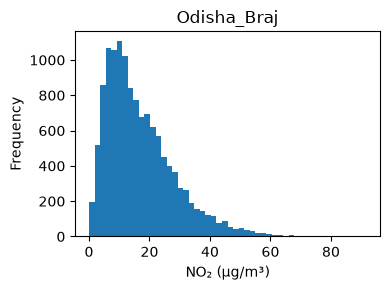

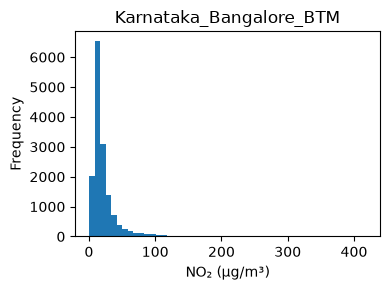

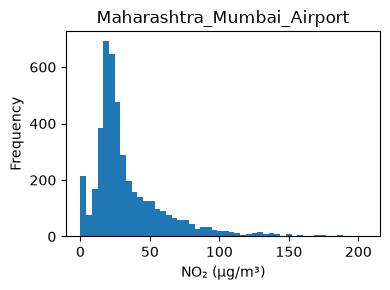

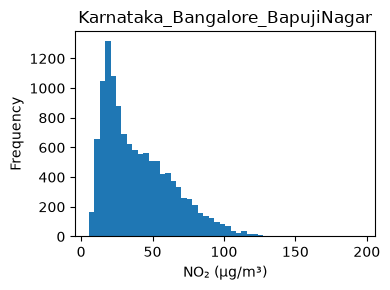

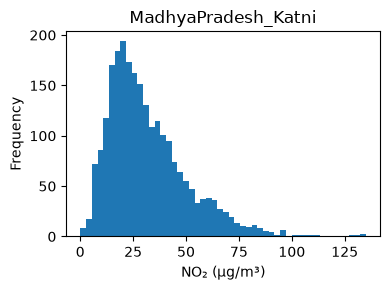

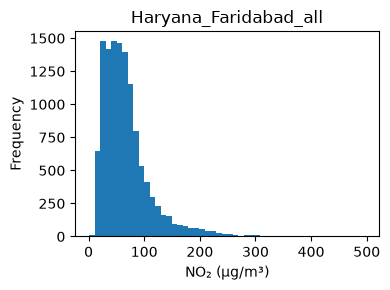

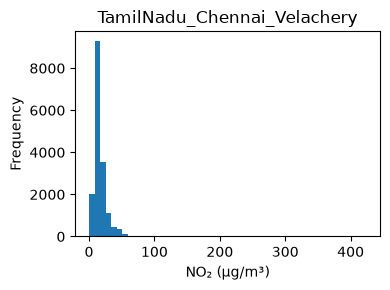

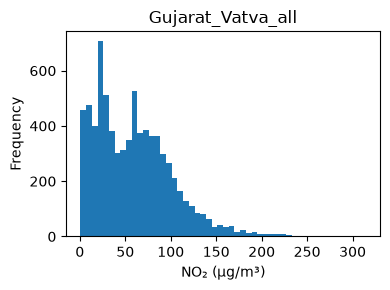

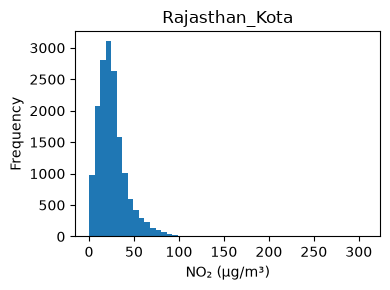

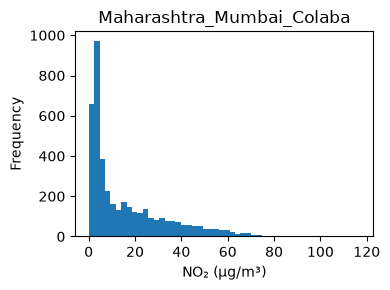

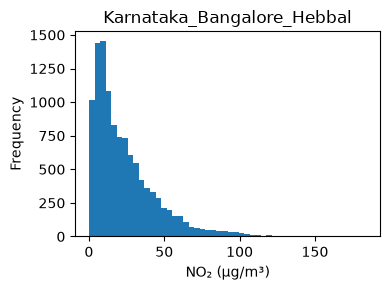

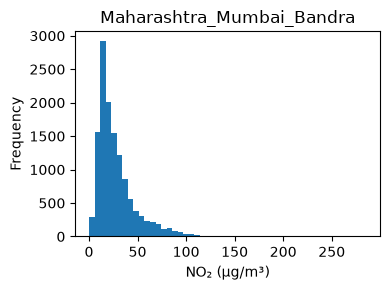

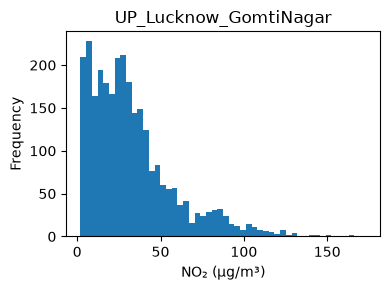

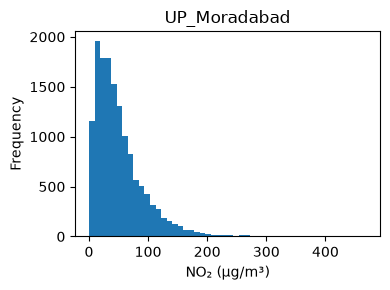

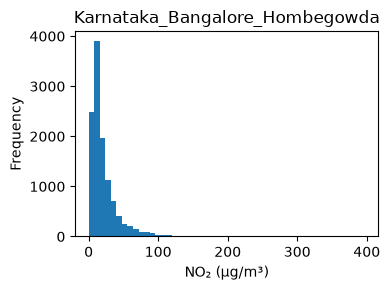

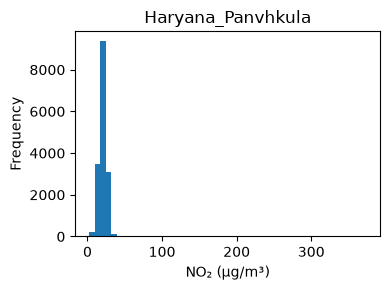

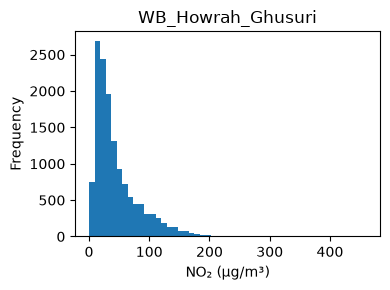

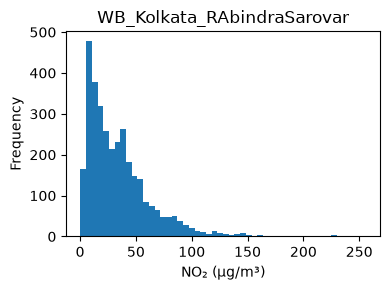

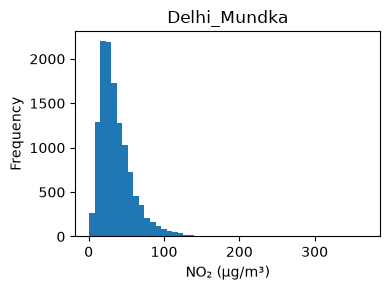

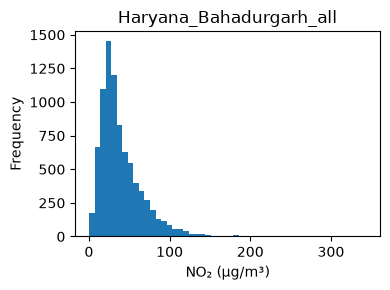

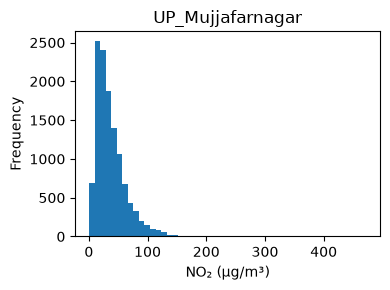

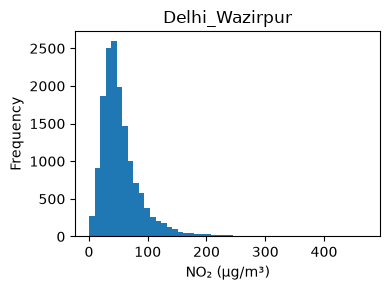

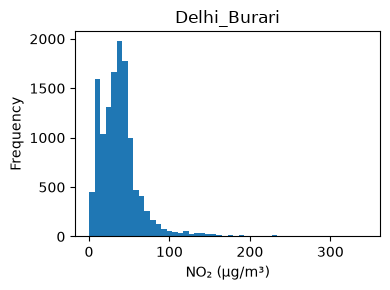

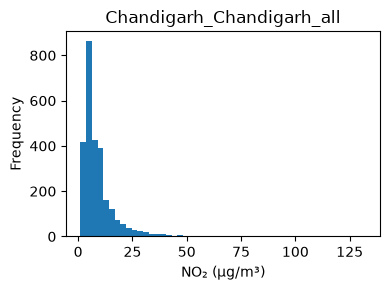

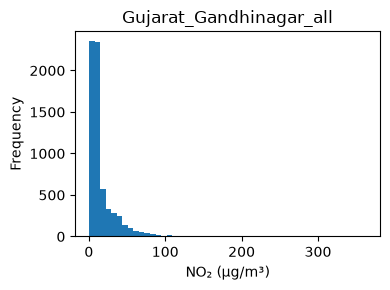

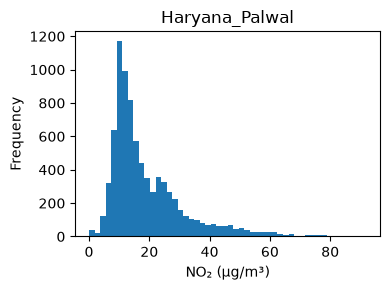

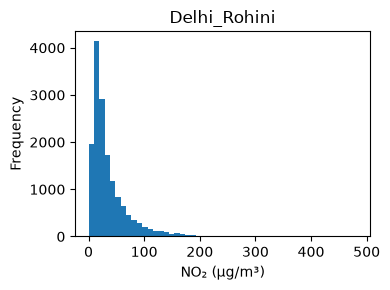

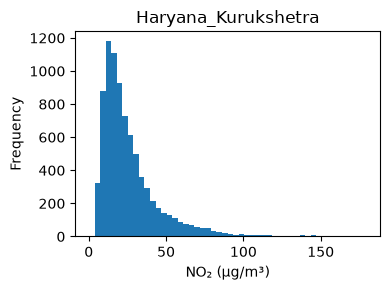

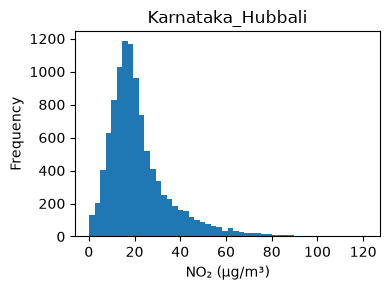

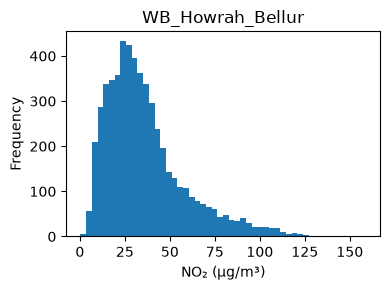

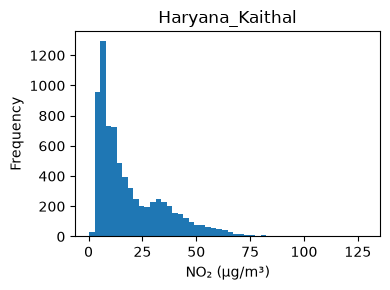

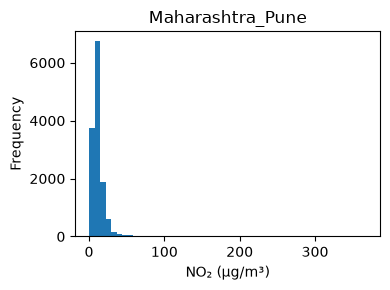

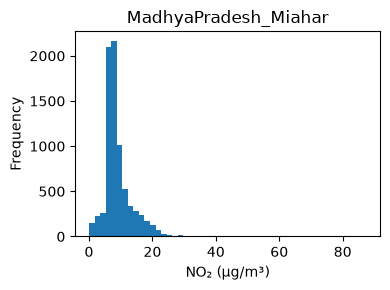

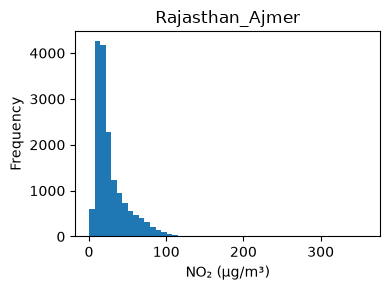

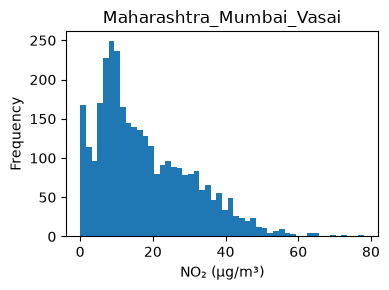

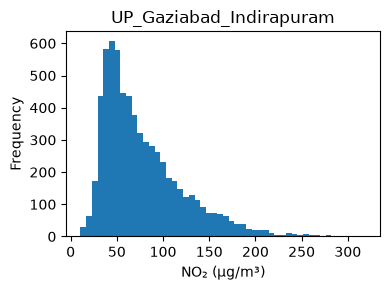

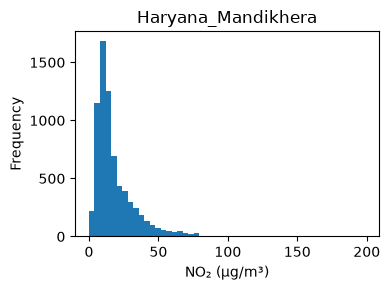

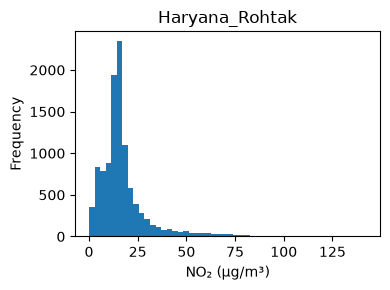

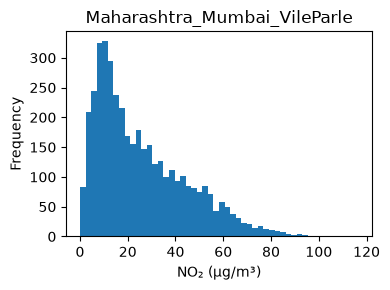

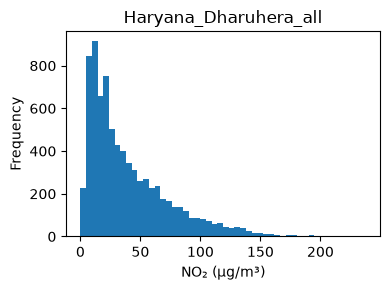

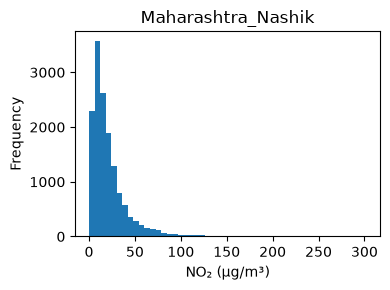

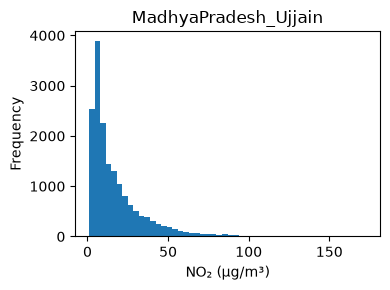

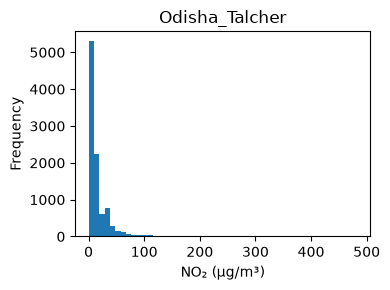

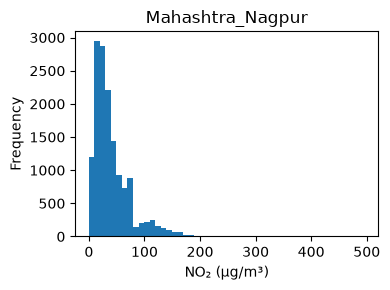

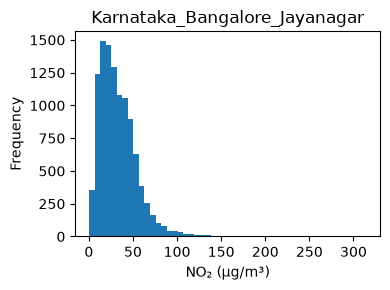

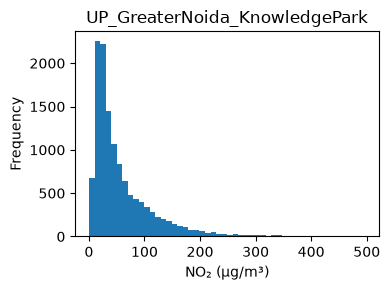

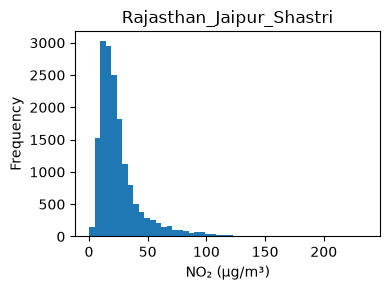

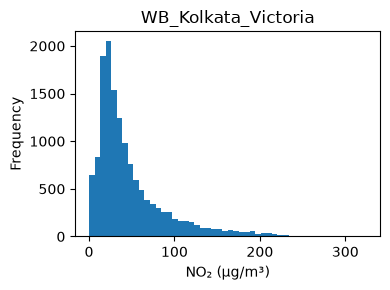

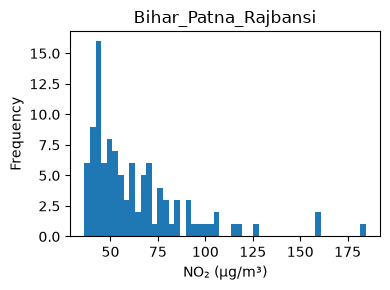

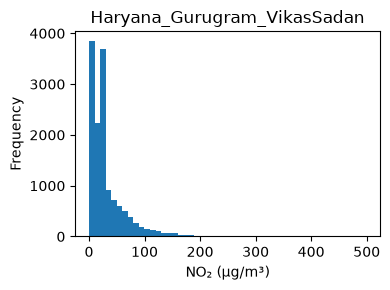

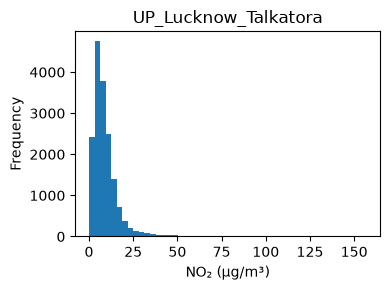

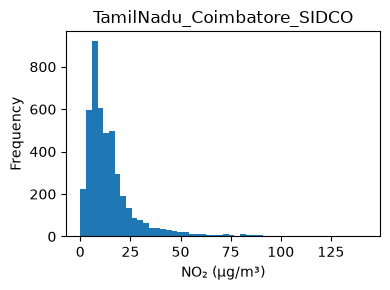

In [10]:
for station in stations:
    plt.figure(figsize=(4, 3))

    ground_no2.loc[
        ground_no2["station"] == station, "NO2"
    ].plot.hist(bins=50)

    plt.title(station)
    plt.xlabel("NO₂ (µg/m³)")

    plt.tight_layout()
    plt.show()

## Check for outliers

In [33]:
outliers = {}

for station in stations:

    no2 = ground_no2.loc[
        ground_no2["station"] == station, "NO2"
    ]

    q1 = no2.quantile(0.25)
    q3 = no2.quantile(0.75)
    iqr = q3-q1

    low_limit = q1 - 1.5 * iqr
    up_limit = q3 + 1.5 * iqr

    n_outlier = no2[(no2 < low_limit) | (no2 > up_limit)].shape[0]
    outliers[station] = (q1, q3, iqr, low_limit, up_limit, n_outlier)
    

In [52]:
df = pd.DataFrame(outliers).T
df.columns=["q1", "q3", "iqr", "low_limit", "up_limit", "n_outlier"]

In [59]:
df["n_outlier"].sum()

np.float64(96058.0)